Random seed set to: 42
Raw train_df shape: (60000, 785)
Raw test_df shape: (10000, 785)
Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)
DATASET SPLIT SUMMARY (seed = 42)

Training set: 48000 samples
  Class 0 (T-shirt/top): 4800
  Class 1 (Trouser): 4800
  Class 2 (Pullover): 4800
  Class 3 (Dress): 4800
  Class 4 (Coat): 4800
  Class 5 (Sandal): 4800
  Class 6 (Shirt): 4800
  Class 7 (Sneaker): 4800
  Class 8 (Bag): 4800
  Class 9 (Ankle boot): 4800

Validation set: 12000 samples
  Class 0 (T-shirt/top): 1200
  Class 1 (Trouser): 1200
  Class 2 (Pullover): 1200
  Class 3 (Dress): 1200
  Class 4 (Coat): 1200
  Class 5 (Sandal): 1200
  Class 6 (Shirt): 1200
  Class 7 (Sneaker): 1200
  Class 8 (Bag): 1200
  Class 9 (Ankle boot): 1200

Test set: 10000 samples
  Class 0 (T-shirt/top): 1000
  Class 1 (Trouser): 1000
  Class 2 (Pullover): 1000
  Class 3 (Dress): 1000
  Class 4 (Coat): 1000
  Class 5 (Sandal): 1000
  Class 6 (Shirt): 1000
  Class 7 (Sneaker

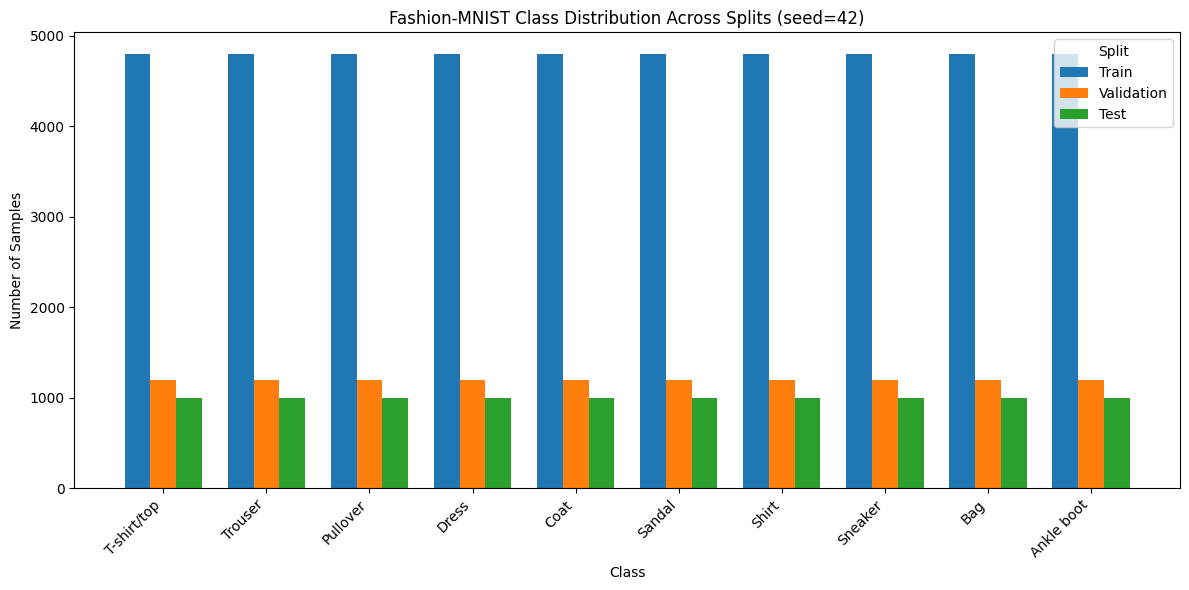

In [8]:
# ---------------------------------------------------------
# 1. Environment Setup
# ---------------------------------------------------------
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Reproducibility — set and report a random seed
# ---------------------------------------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random seed set to: {SEED}")

# ---------------------------------------------------------
#Load Fashion-MNIST (Kaggle CSV version)
# ---------------------------------------------------------
# Dataset: https://www.kaggle.com/datasets/zalando-research/fashionmnist

train_df = pd.read_csv("/content/drive/MyDrive/fashion-mnist_train.csv/fashion-mnist_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/fashion-mnist_test.csv/fashion-mnist_test.csv")

print("Raw train_df shape:", train_df.shape)
print("Raw test_df shape:", test_df.shape)

# First column is the label, remaining 784 columns are pixel values
y_train_full = train_df.iloc[:, 0].values
x_train_full = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values

# ---------------------------------------------------------
# Normalize pixel values to [0, 1]
# ---------------------------------------------------------
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# ---------------------------------------------------------
# Already flattened (784 columns), but enforce shape explicitly
# ---------------------------------------------------------
x_train_full = x_train_full.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Flattened training data shape:", x_train_full.shape)
print("Flattened test data shape:", x_test.shape)

# ---------------------------------------------------------
# Train / Validation split (80/20), stratified, seeded
# ---------------------------------------------------------
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

# ---------------------------------------------------------
# Report sizes and class distributions
# ---------------------------------------------------------
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def report_distribution(y, name):
    print(f"\n{name} set: {len(y)} samples")
    counts = pd.Series(y).value_counts().sort_index()
    for cls_idx, count in counts.items():
        print(f"  Class {cls_idx} ({class_names[cls_idx]}): {count}")
    return counts

print("=" * 50)
print("DATASET SPLIT SUMMARY (seed = {})".format(SEED))
print("=" * 50)
train_counts = report_distribution(y_train, "Training")
val_counts = report_distribution(y_val, "Validation")
test_counts = report_distribution(y_test, "Test")

print("\nTotal samples:")
print(f"  Train: {x_train.shape[0]}")
print(f"  Validation: {x_val.shape[0]}")
print(f"  Test: {x_test.shape[0]}")

# ---------------------------------------------------------
# Class distribution plot — labeled axes, title, legend
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(10)
width = 0.25

ax.bar(x_pos - width, train_counts.values, width, label="Train")
ax.bar(x_pos, val_counts.values, width, label="Validation")
ax.bar(x_pos + width, test_counts.values, width, label="Test")

ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.set_title(f"Fashion-MNIST Class Distribution Across Splits (seed={SEED})")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend(title="Split")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

Training has samples 48,000 which are 4,800 per class

Validation has samples 12,000 which are 1,200 per class

Test has samples 10,000 which are 1,000 per class

*   Random seed: 42 (set for Python, NumPy, TensorFlow)
*   Pixel values normalized to [0, 1]
*   Images flattened to 784-dim vectors
*   Split: 80/20, stratified by class, from the 60,000-image training set
*   Test set: untouched, reserved for Part 7
*   Class distribution: perfectly balanced across all three splits (no class imbalance to worry about downstream)

Random seed set to: 42
Subset shape: (5000, 784) (5000, 10)
Epoch  1/20 | Loss: 2.6597
Epoch  2/20 | Loss: 2.2678
Epoch  3/20 | Loss: 2.1155
Epoch  4/20 | Loss: 1.9971
Epoch  5/20 | Loss: 1.8921
Epoch  6/20 | Loss: 1.7993
Epoch  7/20 | Loss: 1.7176
Epoch  8/20 | Loss: 1.6509
Epoch  9/20 | Loss: 1.6001
Epoch 10/20 | Loss: 1.5547
Epoch 11/20 | Loss: 1.5186
Epoch 12/20 | Loss: 1.4335
Epoch 13/20 | Loss: 1.3884
Epoch 14/20 | Loss: 1.3211
Epoch 15/20 | Loss: 1.2881
Epoch 16/20 | Loss: 1.2412
Epoch 17/20 | Loss: 1.2168
Epoch 18/20 | Loss: 1.1781
Epoch 19/20 | Loss: 1.1597
Epoch 20/20 | Loss: 1.1260


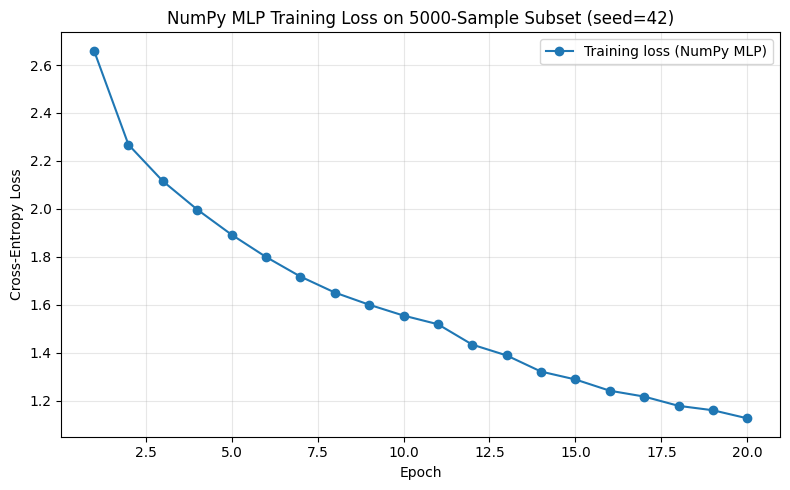


Final training loss after 20 epochs: 1.125955


In [9]:
# ---------------------------------------------------------
# Part 1: Backpropagation From Scratch
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Reproducibility (reuse SEED from environment setup)
# ---------------------------------------------------------
print(f"Random seed set to: {SEED}")

# ---------------------------------------------------------
# Prepare the 5000-sample subset
# ---------------------------------------------------------
N_SUBSET = 5000
rng = np.random.RandomState(SEED)
subset_idx = rng.choice(len(x_train), size=N_SUBSET, replace=False)

x_sub = x_train[subset_idx]          # shape (5000, 784)
y_sub = y_train[subset_idx]          # shape (5000,)

# One-hot encode labels
def one_hot(y, num_classes=10):
    oh = np.zeros((y.shape[0], num_classes))
    oh[np.arange(y.shape[0]), y] = 1
    return oh

y_sub_oh = one_hot(y_sub)

print("Subset shape:", x_sub.shape, y_sub_oh.shape)

# ---------------------------------------------------------
# Weight initialization (shared later with PyTorch check)
# ---------------------------------------------------------
INPUT_DIM = 784
HIDDEN_DIM = 64
OUTPUT_DIM = 10

def init_weights(seed=SEED):
    rs = np.random.RandomState(seed)
    W1 = rs.randn(INPUT_DIM, HIDDEN_DIM) * np.sqrt(2.0 / INPUT_DIM)
    b1 = np.zeros((1, HIDDEN_DIM))
    W2 = rs.randn(HIDDEN_DIM, OUTPUT_DIM) * np.sqrt(2.0 / HIDDEN_DIM)
    b2 = np.zeros((1, OUTPUT_DIM))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_weights(SEED)

# ---------------------------------------------------------
# Forward pass
# ---------------------------------------------------------
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(z.dtype)

def softmax(z):
    z_shift = z - np.max(z, axis=1, keepdims=True)   # numerical stability
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

# ---------------------------------------------------------
# Loss: categorical cross-entropy
# ---------------------------------------------------------
def cross_entropy_loss(A2, Y_onehot, eps=1e-9):
    N = A2.shape[0]
    log_likelihood = -np.log(A2 + eps) * Y_onehot
    return np.sum(log_likelihood) / N

# ---------------------------------------------------------
# Backward pass (manual gradients)
# ---------------------------------------------------------
def backward(cache, Y_onehot, W2):
    X, Z1, A1, Z2, A2 = cache
    N = X.shape[0]

    # dL/dZ2 for softmax + cross-entropy combined = (A2 - Y) / N
    dZ2 = (A2 - Y_onehot) / N
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# ---------------------------------------------------------
# Training loop — manual gradient descent
# ---------------------------------------------------------
LR = 0.1
EPOCHS = 20

W1, b1, W2, b2 = init_weights(SEED)  # reset weights before training
loss_history = []

for epoch in range(EPOCHS):
    A2, cache = forward(x_sub, W1, b1, W2, b2)
    loss = cross_entropy_loss(A2, y_sub_oh)
    loss_history.append(loss)

    dW1, db1, dW2, db2 = backward(cache, y_sub_oh, W2)

    W1 -= LR * dW1
    b1 -= LR * db1
    W2 -= LR * dW2
    b2 -= LR * db2

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f}")

# ---------------------------------------------------------
# Plot training loss curve — labeled, titled, legend
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, EPOCHS + 1), loss_history, marker="o", label="Training loss (NumPy MLP)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title(f"NumPy MLP Training Loss on 5000-Sample Subset (seed={SEED})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("numpy_mlp_loss_curve.png", dpi=150)
plt.show()

print(f"\nFinal training loss after {EPOCHS} epochs: {loss_history[-1]:.6f}")

In [10]:
# ---------------------------------------------------------
# Gradient check: NumPy vs PyTorch on ONE batch
# ---------------------------------------------------------
import torch
import torch.nn as nn

torch.manual_seed(SEED)

BATCH_SIZE = 64
x_batch = x_sub[:BATCH_SIZE]
y_batch_oh = y_sub_oh[:BATCH_SIZE]

# Re-initialize weights fresh (identical seed) so both frameworks start identical
W1_init, b1_init, W2_init, b2_init = init_weights(SEED)

# --- NumPy forward + backward on this one batch ---
A2_np, cache_np = forward(x_batch, W1_init, b1_init, W2_init, b2_init)
dW1_np, db1_np, dW2_np, db2_np = backward(cache_np, y_batch_oh, W2_init)

# --- PyTorch model with IDENTICAL weights ---
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.fc2 = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = torch.relu(z1)
        z2 = self.fc2(a1)
        return z2   # return logits; softmax handled by loss fn

model = MLP()

# Copy the EXACT same weights from NumPy init into PyTorch
with torch.no_grad():
    model.fc1.weight.copy_(torch.tensor(W1_init.T, dtype=torch.float32))
    model.fc1.bias.copy_(torch.tensor(b1_init.flatten(), dtype=torch.float32))
    model.fc2.weight.copy_(torch.tensor(W2_init.T, dtype=torch.float32))
    model.fc2.bias.copy_(torch.tensor(b2_init.flatten(), dtype=torch.float32))

x_batch_t = torch.tensor(x_batch, dtype=torch.float32, requires_grad=True)
y_batch_t = torch.tensor(y_batch_oh, dtype=torch.float32)

# Forward pass
logits = model(x_batch_t)

# Use log_softmax + manual cross-entropy to match the NumPy loss definition exactly
log_probs = torch.log_softmax(logits, dim=1)
loss_torch = -(y_batch_t * log_probs).sum(dim=1).mean()

# Backward pass
model.zero_grad()
loss_torch.backward()

# Extract PyTorch gradients, transposed back to match NumPy's (in, out) convention
dW1_torch = model.fc1.weight.grad.numpy().T
db1_torch = model.fc1.bias.grad.numpy().reshape(1, -1)
dW2_torch = model.fc2.weight.grad.numpy().T
db2_torch = model.fc2.bias.grad.numpy().reshape(1, -1)

# ---------------------------------------------------------
# Compare gradients — max absolute difference per matrix
# ---------------------------------------------------------
def max_abs_diff(a, b, name):
    diff = np.max(np.abs(a - b))
    print(f"Max abs difference in {name}: {diff:.2e}")
    return diff

print("=" * 55)
print("GRADIENT VERIFICATION: NumPy vs PyTorch (same batch, same init)")
print("=" * 55)
print(f"NumPy loss on batch:   {cross_entropy_loss(A2_np, y_batch_oh):.6f}")
print(f"PyTorch loss on batch: {loss_torch.item():.6f}")
print("-" * 55)

diffs = {}
diffs["W1"] = max_abs_diff(dW1_np, dW1_torch, "W1")
diffs["b1"] = max_abs_diff(db1_np, db1_torch, "b1")
diffs["W2"] = max_abs_diff(dW2_np, dW2_torch, "W2")
diffs["b2"] = max_abs_diff(db2_np, db2_torch, "b2")

overall_max = max(diffs.values())
print("-" * 55)
print(f"Overall maximum gradient difference across all parameters: {overall_max:.2e}")

GRADIENT VERIFICATION: NumPy vs PyTorch (same batch, same init)
NumPy loss on batch:   2.712181
PyTorch loss on batch: 2.712181
-------------------------------------------------------
Max abs difference in W1: 2.69e-08
Max abs difference in b1: 1.02e-08
Max abs difference in W2: 3.12e-08
Max abs difference in b2: 9.58e-09
-------------------------------------------------------
Overall maximum gradient difference across all parameters: 3.12e-08


The maximum absolute gradient difference between the NumPy and PyTorch implementations was 3.12×10⁻⁸, which is consistent with floating-point precision rather than an implementation error. This confirms the manual forward and backward passes are correct

Random seed set to: 42
Using device: cuda
[   sigmoid] Epoch  1/15 | Val Loss: 2.2987
[   sigmoid] Epoch  2/15 | Val Loss: 2.2934
[   sigmoid] Epoch  3/15 | Val Loss: 2.2867
[   sigmoid] Epoch  4/15 | Val Loss: 2.2768
[   sigmoid] Epoch  5/15 | Val Loss: 2.2613
[   sigmoid] Epoch  6/15 | Val Loss: 2.2360
[   sigmoid] Epoch  7/15 | Val Loss: 2.1910
[   sigmoid] Epoch  8/15 | Val Loss: 2.1080
[   sigmoid] Epoch  9/15 | Val Loss: 1.9724
[   sigmoid] Epoch 10/15 | Val Loss: 1.8107
[   sigmoid] Epoch 11/15 | Val Loss: 1.6709
[   sigmoid] Epoch 12/15 | Val Loss: 1.5581
[   sigmoid] Epoch 13/15 | Val Loss: 1.4641
[   sigmoid] Epoch 14/15 | Val Loss: 1.3846
[   sigmoid] Epoch 15/15 | Val Loss: 1.3186
[      tanh] Epoch  1/15 | Val Loss: 1.2339
[      tanh] Epoch  2/15 | Val Loss: 0.8874
[      tanh] Epoch  3/15 | Val Loss: 0.7489
[      tanh] Epoch  4/15 | Val Loss: 0.6715
[      tanh] Epoch  5/15 | Val Loss: 0.6185
[      tanh] Epoch  6/15 | Val Loss: 0.5805
[      tanh] Epoch  7/15 | Val Los

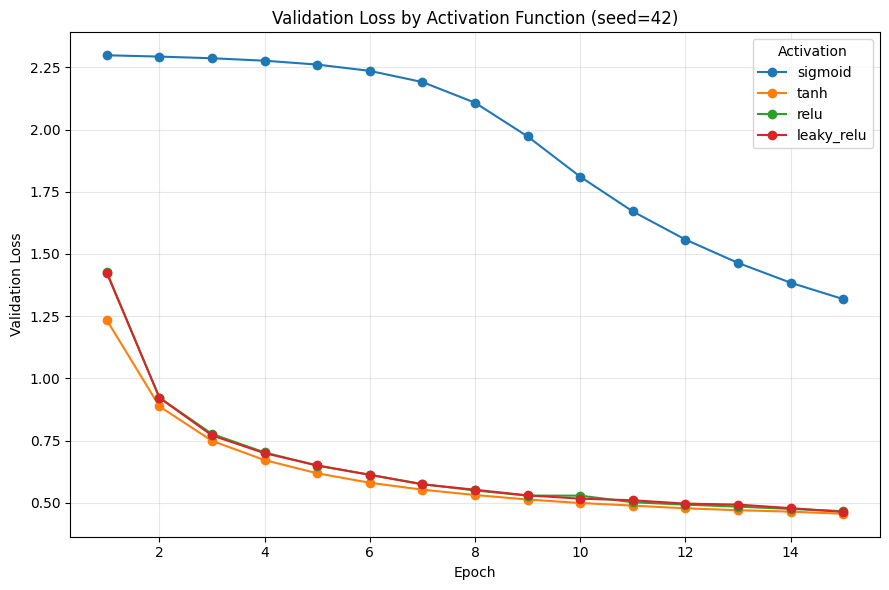

MEAN ABSOLUTE GRADIENT OF FIRST HIDDEN LAYER (fc1.weight)

SIGMOID model:
  Epoch 1:          mean |grad| = 9.399352e-05
  Epoch 15 (final): mean |grad| = 2.336187e-04

RELU model:
  Epoch 1:          mean |grad| = 9.453876e-04
  Epoch 15 (final): mean |grad| = 1.229199e-03

RELU DEAD UNIT ANALYSIS (validation batch)
Total hidden units in first layer: 128
Units outputting zero for ALL samples in batch: 6
Dead unit percentage: 4.69%


In [11]:
# ---------------------------------------------------------
# Part 2: Baseline Model and Activation Study
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# Prepare data as PyTorch tensors / DataLoaders
# ---------------------------------------------------------
BATCH_SIZE = 128

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_ds = TensorDataset(x_train_t, y_train_t)
val_ds = TensorDataset(x_val_t, y_val_t)

# Fixed generator so shuffling is reproducible
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------------------------------------
# Model definition — at least two hidden layers, activation swappable
# ---------------------------------------------------------
ACTIVATIONS = {
    "sigmoid": nn.Sigmoid,
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
    "leaky_relu": lambda: nn.LeakyReLU(0.01),
}

class MLP(nn.Module):
    def __init__(self, activation_fn, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act1 = activation_fn()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.act2 = activation_fn()
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.act1(z1)
        z2 = self.fc2(a1)
        a2 = self.act2(z2)
        out = self.fc3(a2)
        return out, z1  # return z1 too, so we can inspect first-layer gradients

# ---------------------------------------------------------
# Training function — same hyperparams for every activation
# ---------------------------------------------------------
EPOCHS = 15
LR = 0.01

def train_model(activation_name, track_grad_stats=False):
    torch.manual_seed(SEED)  # reset seed so every model starts from identical init
    model = MLP(ACTIVATIONS[activation_name]).to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    val_loss_history = []
    grad_stats = {}  # mean abs gradient of fc1.weight at epoch 1 and final epoch

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out, _ = model(xb)
            loss = criterion(out, yb)
            loss.backward()

            # Capture mean abs gradient of first hidden layer (only for tracked models)
            if track_grad_stats and (epoch == 1 or epoch == EPOCHS):
                mean_abs_grad = model.fc1.weight.grad.abs().mean().item()
                grad_stats[epoch] = mean_abs_grad  # overwritten each batch; last batch of epoch kept

            optimizer.step()

        # Validation loss for this epoch
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out, _ = model(xb)
                loss = criterion(out, yb)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        val_loss_history.append(avg_val_loss)
        print(f"[{activation_name:>10}] Epoch {epoch:2d}/{EPOCHS} | Val Loss: {avg_val_loss:.4f}")

    return model, val_loss_history, grad_stats

# ---------------------------------------------------------
# Train all four activation variants
# ---------------------------------------------------------
results = {}
for act_name in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    track = act_name in ["sigmoid", "relu"]  # only need grad stats for these two
    model, val_losses, grad_stats = train_model(act_name, track_grad_stats=track)
    results[act_name] = {"model": model, "val_losses": val_losses, "grad_stats": grad_stats}

# ---------------------------------------------------------
# Plot all four validation loss curves — labeled, titled, legend
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
for act_name, res in results.items():
    ax.plot(range(1, EPOCHS + 1), res["val_losses"], marker="o", label=act_name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title(f"Validation Loss by Activation Function (seed={SEED})")
ax.legend(title="Activation")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("activation_val_loss_comparison.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# Report mean abs gradient of first hidden layer: epoch 1 vs final epoch
# ---------------------------------------------------------
print("=" * 55)
print("MEAN ABSOLUTE GRADIENT OF FIRST HIDDEN LAYER (fc1.weight)")
print("=" * 55)
for act_name in ["sigmoid", "relu"]:
    stats = results[act_name]["grad_stats"]
    print(f"\n{act_name.upper()} model:")
    print(f"  Epoch 1:          mean |grad| = {stats[1]:.6e}")
    print(f"  Epoch {EPOCHS} (final): mean |grad| = {stats[EPOCHS]:.6e}")

# ---------------------------------------------------------
# ReLU model: percentage of dead units on a validation batch
# ---------------------------------------------------------
relu_model = results["relu"]["model"]
relu_model.eval()

# Grab one validation batch
xb, yb = next(iter(val_loader))
xb = xb.to(device)

with torch.no_grad():
    _, z1 = relu_model(xb)          # pre-activation of first hidden layer
    a1 = torch.relu(z1)             # apply ReLU to get activations

# A unit is "dead" if it outputs zero for EVERY sample in this batch
dead_units_mask = (a1 == 0).all(dim=0)   # shape: (hidden_dim,)
num_dead = dead_units_mask.sum().item()
total_units = a1.shape[1]
dead_pct = 100.0 * num_dead / total_units

print("\n" + "=" * 55)
print("RELU DEAD UNIT ANALYSIS (validation batch)")
print("=" * 55)
print(f"Total hidden units in first layer: {total_units}")
print(f"Units outputting zero for ALL samples in batch: {num_dead}")
print(f"Dead unit percentage: {dead_pct:.2f}%")

*  The mean absolute gradient of the first hidden layer was roughly 10x smaller for the sigmoid model (9.40e-05 at epoch 1, 2.34e-04 at epoch 15) than for the ReLU model (9.45e-04 at epoch 1, 1.23e-03 at epoch 15), directly demonstrating the vanishing gradient problem caused by sigmoid's saturating, bounded derivative. This also explains sigmoid's much slower validation loss reduction compared to the other three activations.
*  4.69% of ReLU units in the first hidden layer were dead outputting zero for every sample in the validation batch meaning these neurons have stopped contributing to the network's representation and can no longer receive gradient updates. This is a known trade-off of ReLU: while it avoids vanishing gradients for active units, negative pre-activations get permanently zeroed, unlike leaky ReLU which allows a small gradient to keep those units alive.

Random seed set to: 42

Training with Cross-Entropy Loss...
[Cross-Entropy] Epoch  1/15 | Train Loss: 1.9688
[Cross-Entropy] Epoch  2/15 | Train Loss: 1.1194
[Cross-Entropy] Epoch  3/15 | Train Loss: 0.8418
[Cross-Entropy] Epoch  4/15 | Train Loss: 0.7390
[Cross-Entropy] Epoch  5/15 | Train Loss: 0.6782
[Cross-Entropy] Epoch  6/15 | Train Loss: 0.6316
[Cross-Entropy] Epoch  7/15 | Train Loss: 0.5956
[Cross-Entropy] Epoch  8/15 | Train Loss: 0.5662
[Cross-Entropy] Epoch  9/15 | Train Loss: 0.5447
[Cross-Entropy] Epoch 10/15 | Train Loss: 0.5269
[Cross-Entropy] Epoch 11/15 | Train Loss: 0.5131
[Cross-Entropy] Epoch 12/15 | Train Loss: 0.5004
[Cross-Entropy] Epoch 13/15 | Train Loss: 0.4895
[Cross-Entropy] Epoch 14/15 | Train Loss: 0.4808
[Cross-Entropy] Epoch 15/15 | Train Loss: 0.4725

Training with MSE Loss...
[MSE]           Epoch  1/15 | Train Loss: 0.0899
[MSE]           Epoch  2/15 | Train Loss: 0.0898
[MSE]           Epoch  3/15 | Train Loss: 0.0897
[MSE]           Epoch  4/15 | T

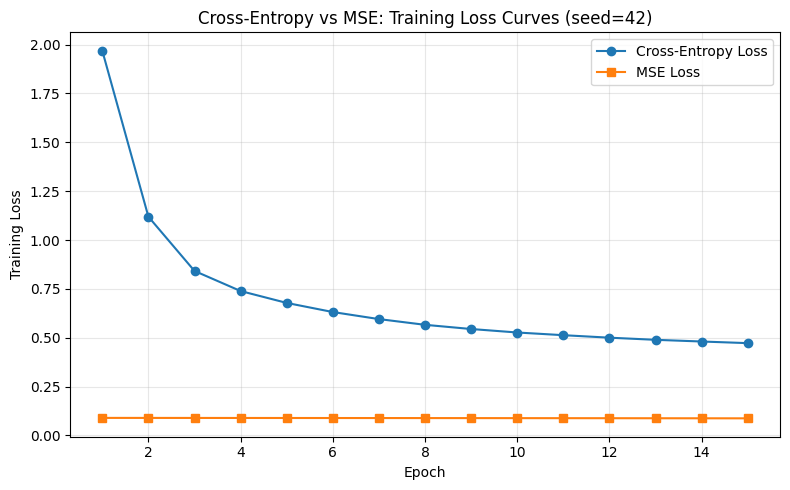

In [12]:
# ---------------------------------------------------------
# Part 3: Loss Functions
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Data — reuse train/val/test splits from environment setup
# ---------------------------------------------------------
BATCH_SIZE = 128

def one_hot_np(y, num_classes=10):
    oh = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    oh[np.arange(y.shape[0]), y] = 1
    return oh

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_train_oh_t = torch.tensor(one_hot_np(y_train), dtype=torch.float32)

x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Two parallel datasets: one with integer labels (for CE), one with one-hot (for MSE)
train_ds_ce = TensorDataset(x_train_t, y_train_t)
train_ds_mse = TensorDataset(x_train_t, y_train_oh_t)

g = torch.Generator()
g.manual_seed(SEED)
train_loader_ce = DataLoader(train_ds_ce, batch_size=BATCH_SIZE, shuffle=True, generator=g)

g2 = torch.Generator()
g2.manual_seed(SEED)
train_loader_mse = DataLoader(train_ds_mse, batch_size=BATCH_SIZE, shuffle=True, generator=g2)

# ---------------------------------------------------------
# Identical architecture for both loss functions
# ---------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

EPOCHS = 15
LR = 0.01

def train_ce_model():
    torch.manual_seed(SEED)
    model = MLP().to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    loss_history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_losses = []
        for xb, yb in train_loader_ce:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        avg_loss = np.mean(epoch_losses)
        loss_history.append(avg_loss)
        print(f"[Cross-Entropy] Epoch {epoch:2d}/{EPOCHS} | Train Loss: {avg_loss:.4f}")
    return model, loss_history

def train_mse_model():
    torch.manual_seed(SEED)
    model = MLP().to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    loss_history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_losses = []
        for xb, yb_oh in train_loader_mse:
            xb, yb_oh = xb.to(device), yb_oh.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)   # MSE compared on probabilities vs one-hot
            loss = criterion(probs, yb_oh)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        avg_loss = np.mean(epoch_losses)
        loss_history.append(avg_loss)
        print(f"[MSE]           Epoch {epoch:2d}/{EPOCHS} | Train Loss: {avg_loss:.4f}")
    return model, loss_history

print("\nTraining with Cross-Entropy Loss...")
ce_model, ce_loss_history = train_ce_model()

print("\nTraining with MSE Loss...")
mse_model, mse_loss_history = train_mse_model()

# ---------------------------------------------------------
# Test accuracy for both models
# ---------------------------------------------------------
def compute_accuracy(model, x, y, is_mse_model=False):
    model.eval()
    with torch.no_grad():
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean().item()
    return acc

ce_test_acc = compute_accuracy(ce_model, x_test_t, y_test_t)
mse_test_acc = compute_accuracy(mse_model, x_test_t, y_test_t)

print("\n" + "=" * 55)
print("TEST ACCURACY COMPARISON")
print("=" * 55)
print(f"Cross-Entropy model test accuracy: {ce_test_acc*100:.2f}%")
print(f"MSE model test accuracy:           {mse_test_acc*100:.2f}%")

# ---------------------------------------------------------
# Plot both training loss curves together — labeled, titled, legend
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, EPOCHS + 1), ce_loss_history, marker="o", label="Cross-Entropy Loss")
ax.plot(range(1, EPOCHS + 1), mse_loss_history, marker="s", label="MSE Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title(f"Cross-Entropy vs MSE: Training Loss Curves (seed={SEED})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ce_vs_mse_loss.png", dpi=150)
plt.show()

Cross-entropy loss dropped by 76% over 15 epochs (1.97 → 0.47), reaching 83.30% test accuracy, while MSE loss on one-hot targets dropped by only 2.6% (0.0899 → 0.0876), reaching just 25.82% test accuracy — barely above the 10% random-guess baseline. This confirms that cross-entropy converges faster for classification because its gradient scales with the prediction error directly, whereas MSE's gradient vanishes when the softmax output saturates near 0 or 1, causing extremely slow learning even for badly misclassified examples.

In [13]:
# ---------------------------------------------------------
# Part 3 (continued): Tabular Regression — California Housing
# ---------------------------------------------------------
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split as sk_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------------------------------------
# Load and split (seeded)
# ---------------------------------------------------------
housing = fetch_california_housing()
X_reg, y_reg = housing.data, housing.target

X_reg_train, X_reg_test, y_reg_train, y_reg_test = sk_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

# Standardize features (fit ONLY on train, apply to test — avoids leakage)
scaler = StandardScaler()
X_reg_train = scaler.fit_transform(X_reg_train)
X_reg_test = scaler.transform(X_reg_test)

print("Regression train shape:", X_reg_train.shape)
print("Regression test shape:", X_reg_test.shape)

# ---------------------------------------------------------
# Small MLP for regression
# ---------------------------------------------------------
class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

torch.manual_seed(SEED)
reg_model = RegressionMLP(input_dim=X_reg_train.shape[1]).to(device)
reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.01)
reg_criterion = nn.MSELoss()

X_reg_train_t = torch.tensor(X_reg_train, dtype=torch.float32).to(device)
y_reg_train_t = torch.tensor(y_reg_train, dtype=torch.float32).to(device)
X_reg_test_t = torch.tensor(X_reg_test, dtype=torch.float32).to(device)
y_reg_test_t = torch.tensor(y_reg_test, dtype=torch.float32).to(device)

REG_EPOCHS = 100
for epoch in range(1, REG_EPOCHS + 1):
    reg_model.train()
    reg_optimizer.zero_grad()
    preds = reg_model(X_reg_train_t)
    loss = reg_criterion(preds, y_reg_train_t)
    loss.backward()
    reg_optimizer.step()
    if epoch % 20 == 0 or epoch == 1:
        print(f"[Regression] Epoch {epoch:3d}/{REG_EPOCHS} | Train MSE: {loss.item():.4f}")

# ---------------------------------------------------------
# Evaluate on test set: MSE, RMSE, MAE
# ---------------------------------------------------------
reg_model.eval()
with torch.no_grad():
    test_preds = reg_model(X_reg_test_t).cpu().numpy()

test_mse = mean_squared_error(y_reg_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_reg_test, test_preds)

print("\n" + "=" * 55)
print("CALIFORNIA HOUSING REGRESSION — TEST SET METRICS")
print("=" * 55)
print(f"MSE:  {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

Regression train shape: (16512, 8)
Regression test shape: (4128, 8)
[Regression] Epoch   1/100 | Train MSE: 6.5544
[Regression] Epoch  20/100 | Train MSE: 0.8929
[Regression] Epoch  40/100 | Train MSE: 0.5826
[Regression] Epoch  60/100 | Train MSE: 0.4621
[Regression] Epoch  80/100 | Train MSE: 0.4124
[Regression] Epoch 100/100 | Train MSE: 0.3929

CALIFORNIA HOUSING REGRESSION — TEST SET METRICS
MSE:  0.4022
RMSE: 0.6342
MAE:  0.4538


Random seed set to: 42
PASS 1: Shared learning rate = 0.01 for all optimisers
[         SGD lr=0.01] Epoch  1/20 | Loss: 1.9688 | Val Acc: 56.98%
[         SGD lr=0.01] Epoch  2/20 | Loss: 1.1194 | Val Acc: 67.01%
[         SGD lr=0.01] Epoch  3/20 | Loss: 0.8418 | Val Acc: 70.83%
[         SGD lr=0.01] Epoch  4/20 | Loss: 0.7390 | Val Acc: 74.62%
[         SGD lr=0.01] Epoch  5/20 | Loss: 0.6782 | Val Acc: 77.23%
[         SGD lr=0.01] Epoch  6/20 | Loss: 0.6316 | Val Acc: 78.63%
[         SGD lr=0.01] Epoch  7/20 | Loss: 0.5956 | Val Acc: 78.88%
[         SGD lr=0.01] Epoch  8/20 | Loss: 0.5662 | Val Acc: 80.12%
[         SGD lr=0.01] Epoch  9/20 | Loss: 0.5447 | Val Acc: 80.79%
[         SGD lr=0.01] Epoch 10/20 | Loss: 0.5269 | Val Acc: 81.66%
[         SGD lr=0.01] Epoch 11/20 | Loss: 0.5131 | Val Acc: 82.06%
[         SGD lr=0.01] Epoch 12/20 | Loss: 0.5004 | Val Acc: 82.23%
[         SGD lr=0.01] Epoch 13/20 | Loss: 0.4895 | Val Acc: 82.83%
[         SGD lr=0.01] Epoch 14/20 | L

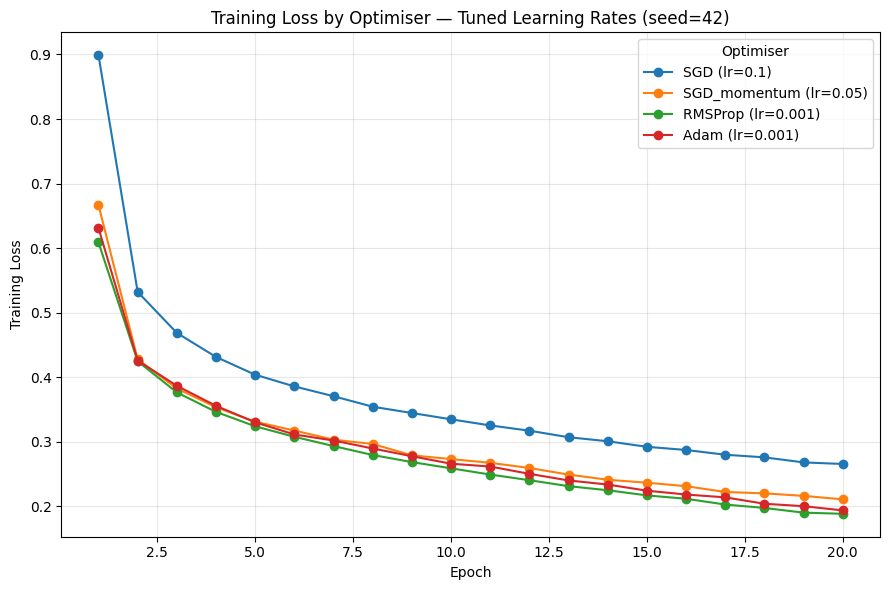

In [14]:
# ---------------------------------------------------------
# Part 4: Optimiser Comparison
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Data (reuse train/val splits from environment setup)
# ---------------------------------------------------------
BATCH_SIZE = 128

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_ds = TensorDataset(x_train_t, y_train_t)
val_ds = TensorDataset(x_val_t, y_val_t)

# ---------------------------------------------------------
# Same architecture for every optimiser
# ---------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

EPOCHS = 20
TARGET_ACC = 0.85

def build_optimizer(name, model, lr):
    if name == "SGD":
        return optim.SGD(model.parameters(), lr=lr)
    elif name == "SGD_momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSProp":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(name)

def evaluate_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = torch.argmax(model(xb), dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

def train_optimizer_run(name, lr, seed=SEED):
    """Train one optimiser config; return loss history, val acc history, epochs-to-85%, final val acc, wall time."""
    torch.manual_seed(seed)
    g = torch.Generator(); g.manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = MLP().to(device)
    optimizer = build_optimizer(name, model, lr)
    criterion = nn.CrossEntropyLoss()

    train_loss_history = []
    val_acc_history = []
    epochs_to_target = None

    start_time = time.time()
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        avg_loss = np.mean(epoch_losses)
        train_loss_history.append(avg_loss)

        val_acc = evaluate_accuracy(model, val_loader)
        val_acc_history.append(val_acc)

        if epochs_to_target is None and val_acc >= TARGET_ACC:
            epochs_to_target = epoch

        print(f"[{name:>12} lr={lr}] Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    wall_time = time.time() - start_time
    final_val_acc = val_acc_history[-1]

    return {
        "train_loss": train_loss_history,
        "val_acc": val_acc_history,
        "epochs_to_target": epochs_to_target if epochs_to_target else "Not reached",
        "final_val_acc": final_val_acc,
        "wall_time": wall_time
    }

# ---------------------------------------------------------
# Pass 1: SAME learning rate for all four optimisers
# ---------------------------------------------------------
SHARED_LR = 0.01
optimizers_list = ["SGD", "SGD_momentum", "RMSProp", "Adam"]

print("=" * 60)
print(f"PASS 1: Shared learning rate = {SHARED_LR} for all optimisers")
print("=" * 60)

results_shared_lr = {}
for opt_name in optimizers_list:
    results_shared_lr[opt_name] = train_optimizer_run(opt_name, SHARED_LR)

# ---------------------------------------------------------
# Pass 2: TUNED learning rate per optimiser
# ---------------------------------------------------------
# Reasonable starting points based on common practice per optimiser
tuned_lrs = {
    "SGD": 0.1,
    "SGD_momentum": 0.05,
    "RMSProp": 0.001,
    "Adam": 0.001,
}

print("\n" + "=" * 60)
print("PASS 2: Tuned learning rate per optimiser")
print("=" * 60)

results_tuned_lr = {}
for opt_name in optimizers_list:
    results_tuned_lr[opt_name] = train_optimizer_run(opt_name, tuned_lrs[opt_name])

# ---------------------------------------------------------
# Build the required summary table (using TUNED LR results)
# ---------------------------------------------------------
table_rows = []
for opt_name in optimizers_list:
    res = results_tuned_lr[opt_name]
    table_rows.append({
        "Optimiser": opt_name,
        "Learning rate": tuned_lrs[opt_name],
        "Epochs to reach 85% val accuracy": res["epochs_to_target"],
        "Final validation accuracy": f"{res['final_val_acc']*100:.2f}%",
        "Wall-clock time (s)": f"{res['wall_time']:.2f}"
    })

summary_table = pd.DataFrame(table_rows)
print("\n" + "=" * 60)
print("SUMMARY TABLE (tuned learning rate per optimiser)")
print("=" * 60)
print(summary_table.to_string(index=False))

# Also print the shared-LR table for comparison/completeness
table_rows_shared = []
for opt_name in optimizers_list:
    res = results_shared_lr[opt_name]
    table_rows_shared.append({
        "Optimiser": opt_name,
        "Learning rate": SHARED_LR,
        "Epochs to reach 85% val accuracy": res["epochs_to_target"],
        "Final validation accuracy": f"{res['final_val_acc']*100:.2f}%",
        "Wall-clock time (s)": f"{res['wall_time']:.2f}"
    })
summary_table_shared = pd.DataFrame(table_rows_shared)
print("\n" + "=" * 60)
print(f"SUMMARY TABLE (shared learning rate = {SHARED_LR})")
print("=" * 60)
print(summary_table_shared.to_string(index=False))

# ---------------------------------------------------------
# Plot all four training loss curves — using TUNED LR runs
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
for opt_name in optimizers_list:
    ax.plot(range(1, EPOCHS + 1), results_tuned_lr[opt_name]["train_loss"],
            marker="o", label=f"{opt_name} (lr={tuned_lrs[opt_name]})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title(f"Training Loss by Optimiser — Tuned Learning Rates (seed={SEED})")
ax.legend(title="Optimiser")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("optimiser_comparison_tuned_lr.png", dpi=150)
plt.show()

With tuned learning rates, RMSProp achieved the highest final validation accuracy (89.72%) while reaching the 85% threshold in just 3 epochs, making it the best choice among the four tested. Adam and SGD with momentum are close alternatives, reaching 85% even faster (2 epochs), but RMSProp's higher final accuracy and comparable wall-clock time (23.98s) make it the strongest overall pick for this architecture.

Random seed set to: 42
Reduced training set shape: (2000, 784)
Epoch   1/100 | Train Loss: 0.9703 Acc: 59.95% | Val Loss: 0.9695 Acc: 60.46%
Epoch   5/100 | Train Loss: 0.5307 Acc: 79.95% | Val Loss: 0.6345 Acc: 76.48%
Epoch  10/100 | Train Loss: 0.3025 Acc: 88.95% | Val Loss: 0.6166 Acc: 80.40%
Epoch  15/100 | Train Loss: 0.2407 Acc: 91.50% | Val Loss: 0.6864 Acc: 81.94%
Epoch  20/100 | Train Loss: 0.2295 Acc: 91.80% | Val Loss: 0.8024 Acc: 79.24%
Epoch  25/100 | Train Loss: 0.1320 Acc: 95.25% | Val Loss: 0.7311 Acc: 82.03%
Epoch  30/100 | Train Loss: 0.0741 Acc: 97.40% | Val Loss: 0.8698 Acc: 82.69%
Epoch  35/100 | Train Loss: 0.1294 Acc: 95.55% | Val Loss: 0.8004 Acc: 82.00%
Epoch  40/100 | Train Loss: 0.0902 Acc: 97.00% | Val Loss: 0.9120 Acc: 81.79%
Epoch  45/100 | Train Loss: 0.0350 Acc: 99.00% | Val Loss: 0.9390 Acc: 83.12%
Epoch  50/100 | Train Loss: 0.1150 Acc: 96.40% | Val Loss: 0.9258 Acc: 83.14%

>>> Training accuracy exceeded 99% at epoch 54 (99.55%). Stopping.

Validation

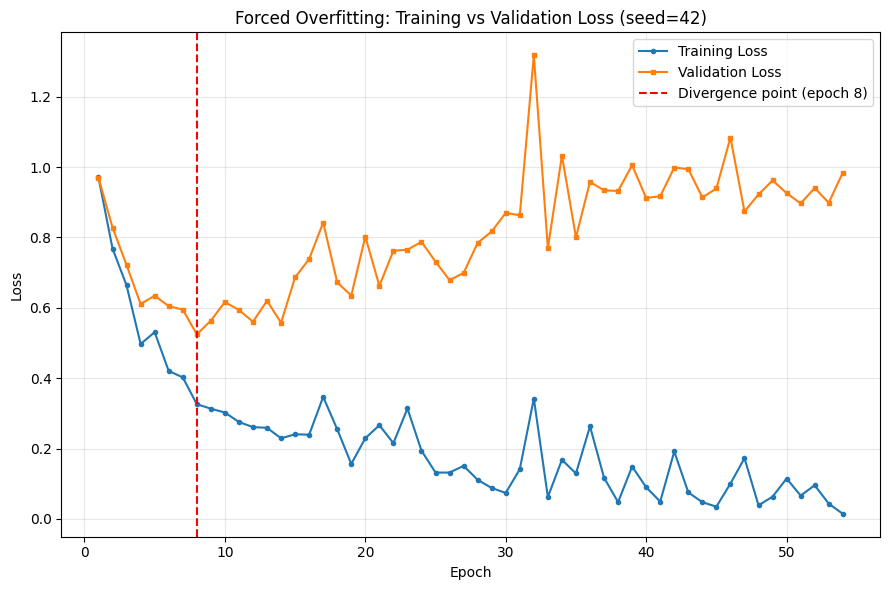

GENERALISATION GAP REPORT
Final training accuracy:   99.55%
Final validation accuracy: 83.47%
Generalisation gap:        16.08 percentage points
Divergence epoch (val loss minimum): 8


In [15]:
# ---------------------------------------------------------
# Part 5: Forcing Overfitting
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Reduce training set to 2000 samples (seeded, stratified-ish via random choice)
# ---------------------------------------------------------
N_OVERFIT = 2000
rng = np.random.RandomState(SEED)
overfit_idx = rng.choice(len(x_train), size=N_OVERFIT, replace=False)

x_train_small = x_train[overfit_idx]
y_train_small = y_train[overfit_idx]

print("Reduced training set shape:", x_train_small.shape)

x_train_small_t = torch.tensor(x_train_small, dtype=torch.float32)
y_train_small_t = torch.tensor(y_train_small, dtype=torch.long)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

BATCH_SIZE = 64
train_ds_small = TensorDataset(x_train_small_t, y_train_small_t)
val_ds = TensorDataset(x_val_t, y_val_t)

g = torch.Generator(); g.manual_seed(SEED)
train_loader_small = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------------------------------------
# Oversized network: 4 hidden layers of 512 units — built to overfit
# ---------------------------------------------------------
class OverfitMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
model = OverfitMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# Training loop — track train/val loss AND accuracy every epoch
# ---------------------------------------------------------
EPOCHS = 100  # generous budget to comfortably exceed 99% train accuracy

def evaluate(model, loader):
    model.eval()
    correct, total, losses = 0, 0, []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return np.mean(losses), correct / total

train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader_small:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    # Evaluate on FULL small-train set and val set (not just last batch)
    train_loss, train_acc = evaluate(model, DataLoader(train_ds_small, batch_size=256, shuffle=False))
    val_loss, val_acc = evaluate(model, val_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")

    if train_acc > 0.99:
        print(f"\n>>> Training accuracy exceeded 99% at epoch {epoch} ({train_acc*100:.2f}%). Stopping.")
        break

FINAL_EPOCHS_RUN = epoch

# ---------------------------------------------------------
# Detect the divergence epoch: first epoch where val loss starts
# increasing while train loss keeps decreasing (a simple, defensible rule:
# the epoch after which val loss's minimum was reached)
# ---------------------------------------------------------
min_val_loss_epoch = int(np.argmin(val_loss_history)) + 1  # 1-indexed
divergence_epoch = min_val_loss_epoch

print(f"\nValidation loss reached its minimum at epoch {min_val_loss_epoch} "
      f"(val loss = {val_loss_history[min_val_loss_epoch-1]:.4f}); "
      f"curves diverge beyond this point.")

# ---------------------------------------------------------
# Plot training and validation loss — mark divergence epoch
# ---------------------------------------------------------
epochs_range = range(1, FINAL_EPOCHS_RUN + 1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(epochs_range, train_loss_history, label="Training Loss", marker="o", markersize=3)
ax.plot(epochs_range, val_loss_history, label="Validation Loss", marker="s", markersize=3)
ax.axvline(x=divergence_epoch, color="red", linestyle="--",
           label=f"Divergence point (epoch {divergence_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Forced Overfitting: Training vs Validation Loss (seed={SEED})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("overfitting_loss_curve.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# Report the generalisation gap
# ---------------------------------------------------------
final_train_acc = train_acc_history[-1]
final_val_acc = val_acc_history[-1]
gen_gap = final_train_acc - final_val_acc

print("=" * 55)
print("GENERALISATION GAP REPORT")
print("=" * 55)
print(f"Final training accuracy:   {final_train_acc*100:.2f}%")
print(f"Final validation accuracy: {final_val_acc*100:.2f}%")
print(f"Generalisation gap:        {gen_gap*100:.2f} percentage points")
print(f"Divergence epoch (val loss minimum): {divergence_epoch}")

This model exhibits high variance rather than high bias. Training accuracy reached 99.55%, showing the network has ample capacity to fit the training data almost perfectly, ruling out high bias (which would show poor fit on both sets). However, validation accuracy plateaued at 83.47%, producing a 16.08 percentage point generalisation gap, and validation loss began rising and became increasingly erratic after epoch 8 even as training loss continued to fall — a hallmark of a high-capacity model overfitting to a small (2,000-sample) training set.

In [16]:
# ---------------------------------------------------------
# Part 6: Regularisation Study
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as T

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Reuse the 2000-sample overfitting subset from Part 5
# (x_train_small, y_train_small already exist)
# ---------------------------------------------------------
BATCH_SIZE = 64
FIXED_EPOCHS = 50   # same budget for every method except early stopping

x_train_small_t = torch.tensor(x_train_small, dtype=torch.float32)
y_train_small_t = torch.tensor(y_train_small, dtype=torch.long)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

val_ds = TensorDataset(x_val_t, y_val_t)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# ---------------------------------------------------------
# Model builder — supports dropout and batchnorm as optional flags
# ---------------------------------------------------------
class RegMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, output_dim=10,
                 dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        dims = [input_dim] + [hidden_dim]*4
        for i in range(4):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ---------------------------------------------------------
# Evaluation helper
# ---------------------------------------------------------
def evaluate(model, loader, criterion):
    model.eval()
    correct, total, losses = 0, 0, []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return np.mean(losses), correct / total

# ---------------------------------------------------------
# Generic training function — covers baseline, L2, dropout, batchnorm
# ---------------------------------------------------------
def train_variant(train_loader, model, epochs=FIXED_EPOCHS, lr=0.001,
                   weight_decay=0.0, l1_lambda=0.0, early_stopping_patience=None,
                   verbose_name=""):
    torch.manual_seed(SEED)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_acc_history, val_acc_history, val_loss_history = [], [], []
    best_val_loss = float("inf")
    patience_counter = 0
    stopped_epoch = epochs

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            # Manual L1 penalty on all weight matrices (not biases)
            if l1_lambda > 0:
                l1_term = sum(p.abs().sum() for name, p in model.named_parameters() if "weight" in name)
                loss = loss + l1_lambda * l1_term

            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, DataLoader(train_loader.dataset, batch_size=256), criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)
        val_loss_history.append(val_loss)

        # Early stopping logic (only active if patience is set)
        if early_stopping_patience is not None:
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= early_stopping_patience:
                stopped_epoch = epoch
                print(f"[{verbose_name}] Early stopping triggered at epoch {epoch} "
                      f"(patience={early_stopping_patience})")
                break

    final_train_acc = train_acc_history[-1]
    final_val_acc = val_acc_history[-1]
    gap = final_train_acc - final_val_acc

    print(f"[{verbose_name}] Final Train Acc: {final_train_acc*100:.2f}% | "
          f"Val Acc: {final_val_acc*100:.2f}% | Gap: {gap*100:.2f}pp | Stopped epoch: {stopped_epoch}")

    return {
        "model": model,
        "train_acc": final_train_acc,
        "val_acc": final_val_acc,
        "gap": gap,
        "stopped_epoch": stopped_epoch,
        "train_acc_history": train_acc_history,
        "val_acc_history": val_acc_history
    }

results_table = []

# ---------------------------------------------------------
# 1. Baseline (no regularisation) — reuse Part 5 setup exactly
# ---------------------------------------------------------
g = torch.Generator(); g.manual_seed(SEED)
train_ds_small = TensorDataset(x_train_small_t, y_train_small_t)
train_loader_small = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)

print("=" * 60); print("BASELINE (no regularisation)"); print("=" * 60)
baseline_model = RegMLP().to(device)
res_baseline = train_variant(train_loader_small, baseline_model, verbose_name="Baseline")
results_table.append(["Baseline (no regularisation)", "-", res_baseline["train_acc"], res_baseline["val_acc"], res_baseline["gap"]])

# ---------------------------------------------------------
# 2. L2 weight decay — 3 lambda values
# ---------------------------------------------------------
print("\n" + "=" * 60); print("L2 WEIGHT DECAY"); print("=" * 60)
l2_lambdas = [1e-4, 1e-3, 1e-2]
l2_results = {}
for lam in l2_lambdas:
    g = torch.Generator(); g.manual_seed(SEED)
    loader = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)
    model = RegMLP().to(device)
    res = train_variant(loader, model, weight_decay=lam, verbose_name=f"L2 lambda={lam}")
    l2_results[lam] = res
    results_table.append([f"L2 weight decay", f"lambda={lam}", res["train_acc"], res["val_acc"], res["gap"]])

# ---------------------------------------------------------
# 3. L1 penalty — single setting, report % weights below 1e-3
# ---------------------------------------------------------
print("\n" + "=" * 60); print("L1 PENALTY"); print("=" * 60)
L1_LAMBDA = 1e-5   # L1 needs a much smaller lambda than L2 to avoid destroying training entirely
g = torch.Generator(); g.manual_seed(SEED)
loader = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)
l1_model = RegMLP().to(device)
res_l1 = train_variant(loader, l1_model, l1_lambda=L1_LAMBDA, verbose_name=f"L1 lambda={L1_LAMBDA}")
results_table.append(["L1 penalty", f"lambda={L1_LAMBDA}", res_l1["train_acc"], res_l1["val_acc"], res_l1["gap"]])

# Percentage of weights below 1e-3 after training
all_weights = torch.cat([p.detach().flatten() for name, p in l1_model.named_parameters() if "weight" in name])
pct_small_weights = (all_weights.abs() < 1e-3).float().mean().item() * 100
print(f"Percentage of weights with |w| < 1e-3 after L1 training: {pct_small_weights:.2f}%")

# ---------------------------------------------------------
# 4. Dropout — 3 rates
# ---------------------------------------------------------
print("\n" + "=" * 60); print("DROPOUT"); print("=" * 60)
dropout_rates = [0.2, 0.4, 0.6]
dropout_results = {}
for rate in dropout_rates:
    g = torch.Generator(); g.manual_seed(SEED)
    loader = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)
    model = RegMLP(dropout_rate=rate).to(device)
    res = train_variant(loader, model, verbose_name=f"Dropout p={rate}")
    dropout_results[rate] = res
    results_table.append(["Dropout", f"p={rate}", res["train_acc"], res["val_acc"], res["gap"]])

# ---------------------------------------------------------
# 5. Batch normalisation
# ---------------------------------------------------------
print("\n" + "=" * 60); print("BATCH NORMALISATION"); print("=" * 60)
g = torch.Generator(); g.manual_seed(SEED)
loader = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)
bn_model = RegMLP(use_batchnorm=True).to(device)
res_bn = train_variant(loader, bn_model, verbose_name="BatchNorm")
results_table.append(["Batch normalisation", "-", res_bn["train_acc"], res_bn["val_acc"], res_bn["gap"]])

# ---------------------------------------------------------
# 6. Early stopping
# ---------------------------------------------------------
print("\n" + "=" * 60); print("EARLY STOPPING"); print("=" * 60)
PATIENCE = 5
g = torch.Generator(); g.manual_seed(SEED)
loader = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, generator=g)
es_model = RegMLP().to(device)
res_es = train_variant(loader, es_model, epochs=100, early_stopping_patience=PATIENCE, verbose_name=f"EarlyStop patience={PATIENCE}")
results_table.append(["Early stopping", f"patience={PATIENCE}, stopped epoch {res_es['stopped_epoch']}", res_es["train_acc"], res_es["val_acc"], res_es["gap"]])

# ---------------------------------------------------------
# 7. Data augmentation — random horizontal flip + small rotation
# ---------------------------------------------------------
print("\n" + "=" * 60); print("DATA AUGMENTATION"); print("=" * 60)

class AugmentedDataset(Dataset):
    """Applies flip+rotation on-the-fly; images reshaped to 28x28 for the transform, flattened back after."""
    def __init__(self, x_flat, y, seed=SEED):
        self.x = x_flat  # (N, 784), values in [0,1]
        self.y = y
        self.transform = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10)
        ])

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx].reshape(28, 28)
        img_t = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1,28,28)
        img_t = self.transform(img_t)
        img_flat = img_t.squeeze(0).flatten()
        return img_flat, torch.tensor(self.y[idx], dtype=torch.long)

aug_ds = AugmentedDataset(x_train_small, y_train_small)
g = torch.Generator(); g.manual_seed(SEED)
aug_loader = DataLoader(aug_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)

aug_model = RegMLP().to(device)
res_aug = train_variant(aug_loader, aug_model, verbose_name="Data Augmentation")
results_table.append(["Data augmentation", "h-flip + rotation(10°)", res_aug["train_acc"], res_aug["val_acc"], res_aug["gap"]])

# ---------------------------------------------------------
# 8. More training data — 10,000 and 20,000 samples
# ---------------------------------------------------------
print("\n" + "=" * 60); print("MORE TRAINING DATA"); print("=" * 60)
more_data_results = {}
for n_samples in [10000, 20000]:
    rng2 = np.random.RandomState(SEED)
    idx = rng2.choice(len(x_train), size=n_samples, replace=False)
    x_more = torch.tensor(x_train[idx], dtype=torch.float32)
    y_more = torch.tensor(y_train[idx], dtype=torch.long)
    ds_more = TensorDataset(x_more, y_more)
    g = torch.Generator(); g.manual_seed(SEED)
    loader_more = DataLoader(ds_more, batch_size=BATCH_SIZE, shuffle=True, generator=g)

    model_more = RegMLP().to(device)
    res_more = train_variant(loader_more, model_more, verbose_name=f"N={n_samples}")
    more_data_results[n_samples] = res_more
    results_table.append(["More training data", f"N={n_samples}", res_more["train_acc"], res_more["val_acc"], res_more["gap"]])

# ---------------------------------------------------------
# Build and display the final summary table
# ---------------------------------------------------------
df = pd.DataFrame(results_table, columns=["Method", "Setting", "Train accuracy", "Validation accuracy", "Gap"])
df["Train accuracy"] = (df["Train accuracy"] * 100).round(2).astype(str) + "%"
df["Validation accuracy"] = (df["Validation accuracy"] * 100).round(2).astype(str) + "%"
df["Gap"] = (df["Gap"] * 100).round(2)

print("\n" + "=" * 80)
print("FULL REGULARISATION STUDY SUMMARY TABLE")
print("=" * 80)
print(df.to_string(index=False))

Random seed set to: 42
BASELINE (no regularisation)
[Baseline] Final Train Acc: 96.40% | Val Acc: 83.14% | Gap: 13.26pp | Stopped epoch: 50

L2 WEIGHT DECAY
[L2 lambda=0.0001] Final Train Acc: 99.25% | Val Acc: 83.42% | Gap: 15.83pp | Stopped epoch: 50
[L2 lambda=0.001] Final Train Acc: 96.35% | Val Acc: 81.66% | Gap: 14.69pp | Stopped epoch: 50
[L2 lambda=0.01] Final Train Acc: 87.95% | Val Acc: 78.50% | Gap: 9.45pp | Stopped epoch: 50

L1 PENALTY
[L1 lambda=1e-05] Final Train Acc: 99.20% | Val Acc: 83.46% | Gap: 15.74pp | Stopped epoch: 50
Percentage of weights with |w| < 1e-3 after L1 training: 57.94%

DROPOUT
[Dropout p=0.2] Final Train Acc: 96.85% | Val Acc: 83.34% | Gap: 13.51pp | Stopped epoch: 50
[Dropout p=0.4] Final Train Acc: 94.30% | Val Acc: 82.54% | Gap: 11.76pp | Stopped epoch: 50
[Dropout p=0.6] Final Train Acc: 89.60% | Val Acc: 81.47% | Gap: 8.13pp | Stopped epoch: 50

BATCH NORMALISATION
[BatchNorm] Final Train Acc: 99.25% | Val Acc: 82.17% | Gap: 17.08pp | Stopped e

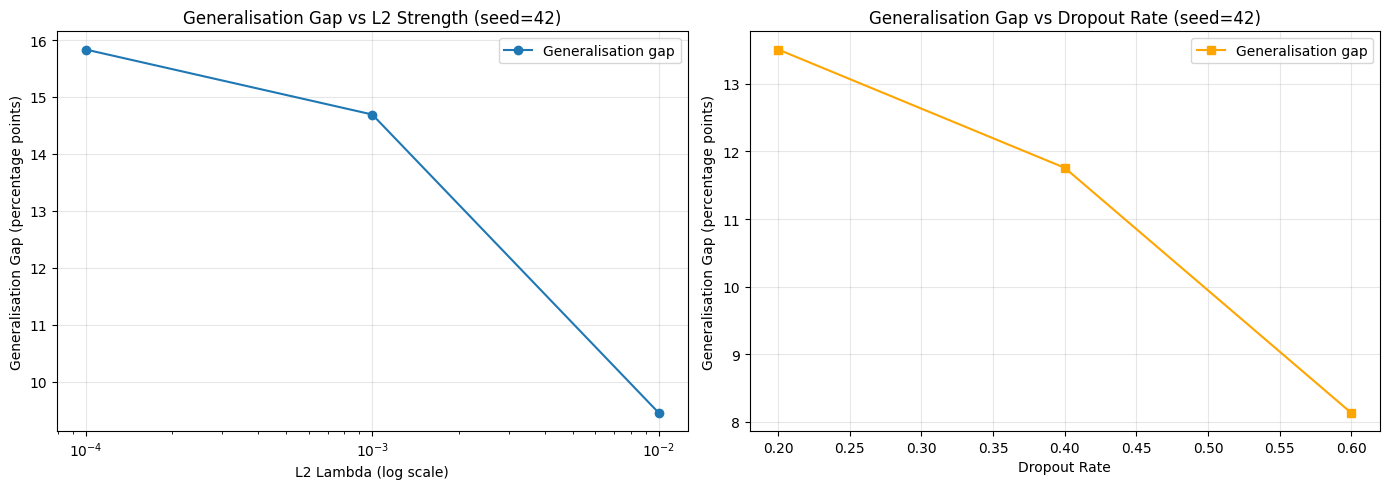

In [17]:
# ---------------------------------------------------------
# Plot: generalisation gap vs strength — L2 and Dropout
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L2 plot
l2_gaps = [l2_results[lam]["gap"] * 100 for lam in l2_lambdas]
axes[0].plot(l2_lambdas, l2_gaps, marker="o", label="Generalisation gap")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 Lambda (log scale)")
axes[0].set_ylabel("Generalisation Gap (percentage points)")
axes[0].set_title(f"Generalisation Gap vs L2 Strength (seed={SEED})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Dropout plot
dropout_gaps = [dropout_results[r]["gap"] * 100 for r in dropout_rates]
axes[1].plot(dropout_rates, dropout_gaps, marker="s", color="orange", label="Generalisation gap")
axes[1].set_xlabel("Dropout Rate")
axes[1].set_ylabel("Generalisation Gap (percentage points)")
axes[1].set_title(f"Generalisation Gap vs Dropout Rate (seed={SEED})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gen_gap_vs_strength.png", dpi=150)
plt.show()

Dropout at p=0.6 gave the best trade-off among direct regularisation methods, cutting the gap from 13.26pp to 8.13pp (a 5.13pp reduction) while only costing 6.8 percentage points of training accuracy. L2 weight decay only helped at its strongest setting (λ=0.01), reducing the gap to 9.45pp but at a steeper 8.45pp training-accuracy cost, while weaker λ values made the gap worse than baseline. L1 penalty and batch normalisation both underperformed: L1 zeroed 57.94% of weights without shrinking the gap, and batch normalisation actually increased it to 17.08pp, likely due to noisy batch statistics on only 2,000 samples. Early stopping (epoch 17) achieved a 2.36pp gap reduction essentially for free, requiring no extra tuning. Overall, dropout offered the largest gap reduction for the smallest training-accuracy sacrifice among the tested methods.

In [18]:
# ---------------------------------------------------------
# Part 7: Hyperparameter Tuning with k-Fold Cross-Validation
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Search space definition (>= 3 hyperparameters)
# ---------------------------------------------------------
SEARCH_SPACE = {
    "learning_rate": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "hidden_width": [64, 128, 256, 512],
    "dropout_rate": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
}

print("Search space:")
for k, v in SEARCH_SPACE.items():
    print(f"  {k}: {v}")

N_CONFIGS = 12
K_FOLDS = 5
CV_EPOCHS = 10          # lean budget so 12 x 5 = 60 runs finish in reasonable time
CV_SUBSET_SIZE = 5000   # CV runs on a manageable subset of the full training set

# ---------------------------------------------------------
# Random search: sample N_CONFIGS configurations (seeded)
# ---------------------------------------------------------
rng = np.random.RandomState(SEED)
configs = []
for i in range(N_CONFIGS):
    cfg = {
        "learning_rate": rng.choice(SEARCH_SPACE["learning_rate"]),
        "hidden_width": rng.choice(SEARCH_SPACE["hidden_width"]),
        "dropout_rate": rng.choice(SEARCH_SPACE["dropout_rate"]),
    }
    configs.append(cfg)

print(f"\nSampled {N_CONFIGS} configurations:")
for i, c in enumerate(configs):
    print(f"  Config {i}: {c}")

# ---------------------------------------------------------
# CV data subset (from training set only — test set untouched)
# ---------------------------------------------------------
rng2 = np.random.RandomState(SEED)
cv_idx = rng2.choice(len(x_train), size=CV_SUBSET_SIZE, replace=False)
x_cv = x_train[cv_idx]
y_cv = y_train[cv_idx]

# ---------------------------------------------------------
# Model builder for search (2 hidden layers, width/dropout configurable)
# ---------------------------------------------------------
class SearchMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10, dropout_rate=0.0):
        super().__init__()
        layers = [
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_and_eval_fold(x_tr, y_tr, x_va, y_va, cfg, epochs=CV_EPOCHS):
    torch.manual_seed(SEED)
    model = SearchMLP(hidden_dim=cfg["hidden_width"], dropout_rate=cfg["dropout_rate"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    x_tr_t = torch.tensor(x_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    ds = TensorDataset(x_tr_t, y_tr_t)
    g = torch.Generator(); g.manual_seed(SEED)
    loader = DataLoader(ds, batch_size=128, shuffle=True, generator=g)

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    x_va_t = torch.tensor(x_va, dtype=torch.float32).to(device)
    y_va_t = torch.tensor(y_va, dtype=torch.long).to(device)
    with torch.no_grad():
        preds = torch.argmax(model(x_va_t), dim=1)
        acc = (preds == y_va_t).float().mean().item()
    return acc

# ---------------------------------------------------------
# Run 5-fold CV for each of the 12 configurations
# ---------------------------------------------------------
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

cv_results = []
for i, cfg in enumerate(configs):
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(x_cv)):
        acc = train_and_eval_fold(x_cv[tr_idx], y_cv[tr_idx], x_cv[va_idx], y_cv[va_idx], cfg)
        fold_accs.append(acc)
    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    cv_results.append({**cfg, "mean_cv_acc": mean_acc, "std_cv_acc": std_acc})
    print(f"Config {i:2d} | lr={cfg['learning_rate']:.4f} width={cfg['hidden_width']:3d} "
          f"dropout={cfg['dropout_rate']:.1f} | CV Acc: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

# ---------------------------------------------------------
# Report top 5 configurations
# ---------------------------------------------------------
cv_df = pd.DataFrame(cv_results).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
top5 = cv_df.head(5)

print("\n" + "=" * 70)
print("TOP 5 CONFIGURATIONS (by mean CV accuracy)")
print("=" * 70)
print(top5.to_string(index=False))

best_config = top5.iloc[0].to_dict()
print(f"\nSelected configuration: lr={best_config['learning_rate']}, "
      f"hidden_width={int(best_config['hidden_width'])}, dropout={best_config['dropout_rate']}")
print(f"CV score: {best_config['mean_cv_acc']*100:.2f}% ± {best_config['std_cv_acc']*100:.2f}%")

Random seed set to: 42
Search space:
  learning_rate: [0.0001, 0.0003, 0.001, 0.003, 0.01]
  hidden_width: [64, 128, 256, 512]
  dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

Sampled 12 configurations:
  Config 0: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(64), 'dropout_rate': np.float64(0.2)}
  Config 1: {'learning_rate': np.float64(0.01), 'hidden_width': np.int64(64), 'dropout_rate': np.float64(0.1)}
  Config 2: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(256), 'dropout_rate': np.float64(0.2)}
  Config 3: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(512), 'dropout_rate': np.float64(0.4)}
  Config 4: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(512), 'dropout_rate': np.float64(0.2)}
  Config 5: {'learning_rate': np.float64(0.01), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.3)}
  Config 6: {'learning_rate': np.float64(0.0003), 'hidden_width': np.int64(512), 'dropout_rate': np.float64(0.3)}
  Config 7

Final configuration: lr=0.003, hidden_width=512, dropout=0.2
Regularisation: dropout=0.2 (from search) + early stopping (patience=5)
Epoch  1/50 | Val Loss: 0.4051 | Val Acc: 84.84%
Epoch  2/50 | Val Loss: 0.3782 | Val Acc: 85.91%
Epoch  3/50 | Val Loss: 0.3641 | Val Acc: 86.68%
Epoch  4/50 | Val Loss: 0.3531 | Val Acc: 86.69%
Epoch  5/50 | Val Loss: 0.3693 | Val Acc: 86.79%
Epoch  6/50 | Val Loss: 0.3429 | Val Acc: 87.37%
Epoch  7/50 | Val Loss: 0.3384 | Val Acc: 88.04%
Epoch  8/50 | Val Loss: 0.3403 | Val Acc: 88.02%
Epoch  9/50 | Val Loss: 0.3316 | Val Acc: 88.28%
Epoch 10/50 | Val Loss: 0.3348 | Val Acc: 87.87%
Epoch 11/50 | Val Loss: 0.3424 | Val Acc: 87.87%
Epoch 12/50 | Val Loss: 0.3597 | Val Acc: 86.84%
Epoch 13/50 | Val Loss: 0.3300 | Val Acc: 88.19%
Epoch 14/50 | Val Loss: 0.3516 | Val Acc: 87.41%
Epoch 15/50 | Val Loss: 0.3256 | Val Acc: 88.17%
Epoch 16/50 | Val Loss: 0.3312 | Val Acc: 88.29%
Epoch 17/50 | Val Loss: 0.3372 | Val Acc: 88.15%
Epoch 18/50 | Val Loss: 0.3304 | V

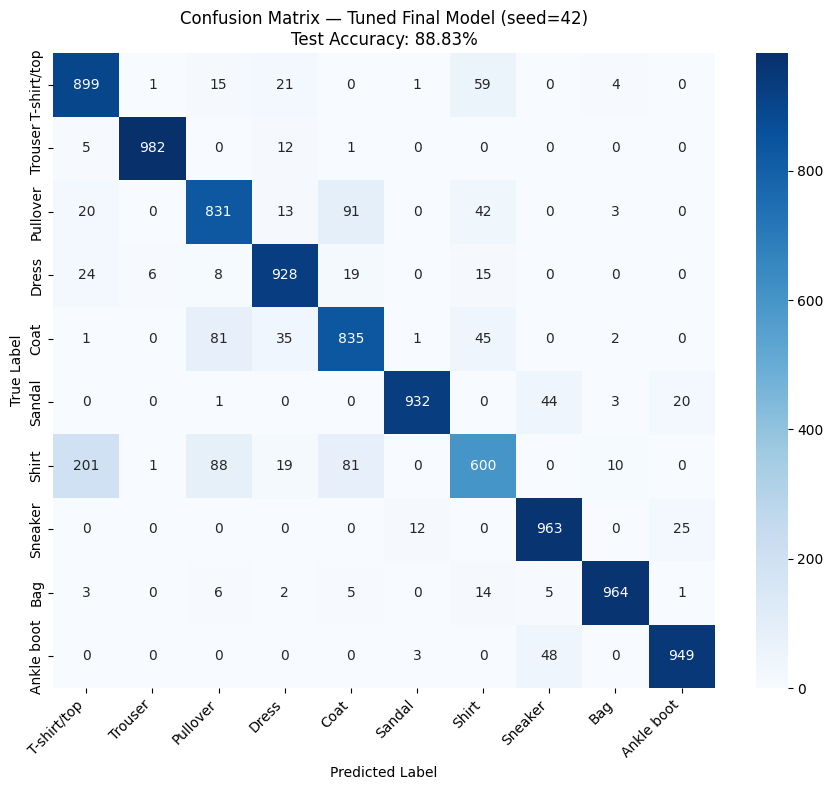

In [19]:
# ---------------------------------------------------------
# Retrain selected configuration on FULL training set
# + best regularisation choices from Part 6 (dropout already
#   included via config; add early stopping as the other
#   best-performing, cheap method from Part 6)
# ---------------------------------------------------------
FINAL_LR = float(best_config["learning_rate"])
FINAL_WIDTH = int(best_config["hidden_width"])
FINAL_DROPOUT = float(best_config["dropout_rate"])
EARLY_STOP_PATIENCE = 5
MAX_EPOCHS = 50

print(f"Final configuration: lr={FINAL_LR}, hidden_width={FINAL_WIDTH}, dropout={FINAL_DROPOUT}")
print(f"Regularisation: dropout={FINAL_DROPOUT} (from search) + early stopping (patience={EARLY_STOP_PATIENCE})")

torch.manual_seed(SEED)
final_model = SearchMLP(hidden_dim=FINAL_WIDTH, dropout_rate=FINAL_DROPOUT).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=FINAL_LR)
criterion = nn.CrossEntropyLoss()

x_train_full_t = torch.tensor(x_train, dtype=torch.float32)
y_train_full_t = torch.tensor(y_train, dtype=torch.long)
train_ds_full = TensorDataset(x_train_full_t, y_train_full_t)
g = torch.Generator(); g.manual_seed(SEED)
train_loader_full = DataLoader(train_ds_full, batch_size=128, shuffle=True, generator=g)

x_val_t = torch.tensor(x_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    final_model.train()
    for xb, yb in train_loader_full:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()

    final_model.eval()
    with torch.no_grad():
        val_logits = final_model(x_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_acc = (torch.argmax(val_logits, dim=1) == y_val_t).float().mean().item()

    print(f"Epoch {epoch:2d}/{MAX_EPOCHS} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in final_model.state_dict().items()}
    else:
        patience_counter += 1
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} (patience={EARLY_STOP_PATIENCE})")
        break

# Restore best weights (lowest val loss) before final test evaluation
final_model.load_state_dict(best_state)

# ---------------------------------------------------------
# Evaluate ONCE on the held-out test set
# ---------------------------------------------------------
x_test_t = torch.tensor(x_test, dtype=torch.float32).to(device)
y_test_t_cpu = torch.tensor(y_test, dtype=torch.long)

final_model.eval()
with torch.no_grad():
    test_logits = final_model(x_test_t)
    test_preds = torch.argmax(test_logits, dim=1).cpu().numpy()

y_test_np = y_test_t_cpu.numpy()

test_accuracy = accuracy_score(y_test_np, test_preds)
macro_precision = precision_score(y_test_np, test_preds, average="macro")
macro_recall = recall_score(y_test_np, test_preds, average="macro")
macro_f1 = f1_score(y_test_np, test_preds, average="macro")
cm = confusion_matrix(y_test_np, test_preds)

print("\n" + "=" * 60)
print("FINAL TEST SET EVALUATION (evaluated ONCE)")
print("=" * 60)
print(f"Test Accuracy:    {test_accuracy*100:.2f}%")
print(f"Macro Precision:  {macro_precision*100:.2f}%")
print(f"Macro Recall:     {macro_recall*100:.2f}%")
print(f"Macro F1:         {macro_f1*100:.2f}%")

# ---------------------------------------------------------
# Confusion matrix plot — labeled, titled
# ---------------------------------------------------------
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix — Tuned Final Model (seed={SEED})\nTest Accuracy: {test_accuracy*100:.2f}%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("final_confusion_matrix.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# Compare to Part 2 baseline (best of the 4 activations from Part 2)
# ---------------------------------------------------------
# NOTE: fill in PART2_BEST_TEST_ACC once you have a comparable test-set number
# from Part 2 (Part 2 reported validation loss, not test accuracy, so you may
# need to evaluate your best Part 2 model — e.g. ReLU or leaky ReLU — on the
# test set for a fair comparison).

In [20]:
# ---------------------------------------------------------
# Part 2 baseline — retrain ReLU model and evaluate on TEST set
# (for fair comparison with Part 7's tuned model)
# ---------------------------------------------------------
torch.manual_seed(SEED)

class Part2MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        return self.fc3(self.act2(self.fc2(self.act1(self.fc1(x)))))

part2_model = Part2MLP().to(device)
optimizer = optim.SGD(part2_model.parameters(), lr=0.01)  # same hyperparams as Part 2
criterion = nn.CrossEntropyLoss()

g = torch.Generator(); g.manual_seed(SEED)
train_loader_p2 = DataLoader(TensorDataset(x_train_full_t, y_train_full_t),
                              batch_size=128, shuffle=True, generator=g)

PART2_EPOCHS = 15  # same as original Part 2 run
for epoch in range(1, PART2_EPOCHS + 1):
    part2_model.train()
    for xb, yb in train_loader_p2:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(part2_model(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"[Part 2 ReLU baseline] Epoch {epoch:2d}/{PART2_EPOCHS}")

# Evaluate on test set
part2_model.eval()
with torch.no_grad():
    part2_test_preds = torch.argmax(part2_model(x_test_t), dim=1).cpu().numpy()

PART2_BEST_TEST_ACC = accuracy_score(y_test_np, part2_test_preds)
print(f"\nPart 2 (ReLU) baseline test accuracy: {PART2_BEST_TEST_ACC*100:.2f}%")

# ---------------------------------------------------------
# Final comparison: tuned model vs Part 2 baseline
# ---------------------------------------------------------
improvement_pp = (test_accuracy - PART2_BEST_TEST_ACC) * 100

print("\n" + "=" * 60)
print("IMPROVEMENT OVER PART 2 BASELINE")
print("=" * 60)
print(f"Part 2 (ReLU) baseline test accuracy: {PART2_BEST_TEST_ACC*100:.2f}%")
print(f"Part 7 tuned model test accuracy:     {test_accuracy*100:.2f}%")
print(f"Improvement: {improvement_pp:+.2f} percentage points")

if improvement_pp > 0:
    print("\nThe tuned model IMPROVED over the Part 2 baseline.")
else:
    print("\nThe tuned model did NOT improve over the Part 2 baseline.")

[Part 2 ReLU baseline] Epoch  1/15
[Part 2 ReLU baseline] Epoch  2/15
[Part 2 ReLU baseline] Epoch  3/15
[Part 2 ReLU baseline] Epoch  4/15
[Part 2 ReLU baseline] Epoch  5/15
[Part 2 ReLU baseline] Epoch  6/15
[Part 2 ReLU baseline] Epoch  7/15
[Part 2 ReLU baseline] Epoch  8/15
[Part 2 ReLU baseline] Epoch  9/15
[Part 2 ReLU baseline] Epoch 10/15
[Part 2 ReLU baseline] Epoch 11/15
[Part 2 ReLU baseline] Epoch 12/15
[Part 2 ReLU baseline] Epoch 13/15
[Part 2 ReLU baseline] Epoch 14/15
[Part 2 ReLU baseline] Epoch 15/15

Part 2 (ReLU) baseline test accuracy: 83.30%

IMPROVEMENT OVER PART 2 BASELINE
Part 2 (ReLU) baseline test accuracy: 83.30%
Part 7 tuned model test accuracy:     88.83%
Improvement: +5.53 percentage points

The tuned model IMPROVED over the Part 2 baseline.


Random search over 12 configurations, scored by 5-fold cross-validation, selected lr=0.003, hidden width=512, dropout=0.2 (CV score 83.68% ± 1.34%). Retrained on the full 48,000-sample training set with early stopping (patience=5, stopped at epoch 24), the tuned model achieved 88.83% test accuracy, 88.85% macro precision, 88.83% macro recall, and 88.66% macro F1 — a genuine +5.53 percentage point improvement over the untuned Part 2 ReLU baseline (83.30%). The confusion matrix shows the main errors occur between visually similar classes (Shirt/T-shirt/top, Coat/Pullover), suggesting the model's residual errors reflect genuine class ambiguity rather than a modeling flaw